In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Dataset

df = pd.read_csv("housing.csv")

In [4]:
# Display First Five Records

print(df.head())

# Display Numerical Columns

print(df.select_dtypes(include="number").columns)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
      

In [5]:
# Calculate Correlation Matrix

correlation = df.corr(numeric_only=True)
print(correlation)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

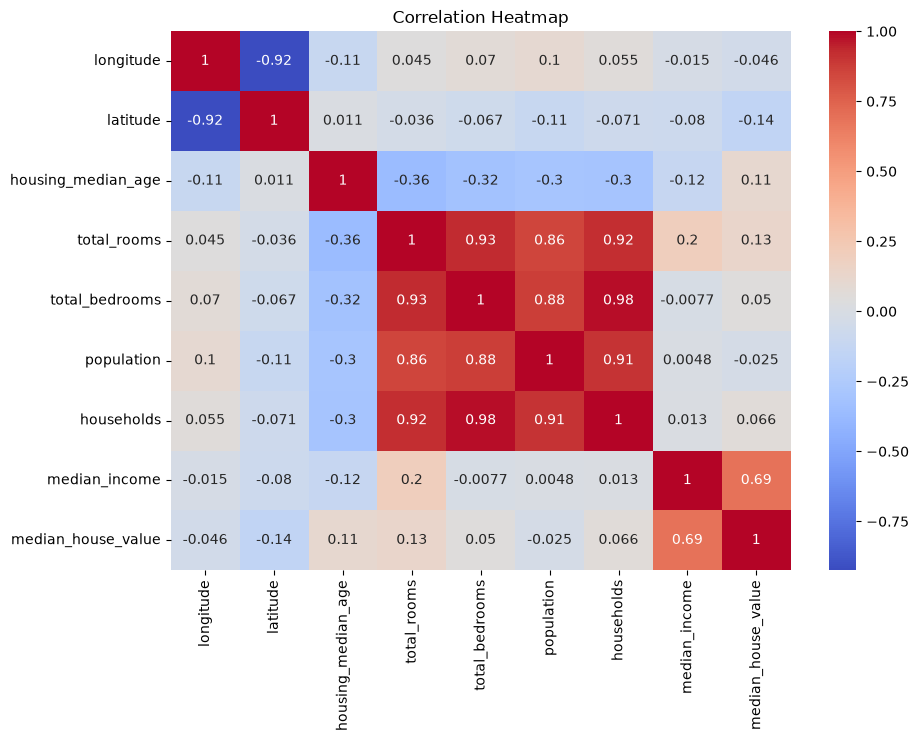

In [6]:
# Display Correlation Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# Select Independent and Dependent Variables
X = df[["median_income"]]
y = df["median_house_value"]

In [9]:
# Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Create Linear Regression Model

model = LinearRegression()

In [11]:
# Train the Model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41933.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.446e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
# Display Coefficient and Intercept
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 41933.84939381274
Intercept: 44459.729169078666


In [ ]:
# Predict House Values
y_pred = model.predict(X_test)

In [ ]:
# Display First 10 Predictions
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[114958.91676996 150606.88213964 190393.71844449 285059.38345102
 200663.31816103 242165.24890609 257647.22610228 199229.18051176
 245893.1681172  384677.43607096]


In [15]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 7091157771.76555


In [18]:
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
print("Aashu Yadav")

R2 Score: 0.45885918903846656
Aashu Yadav


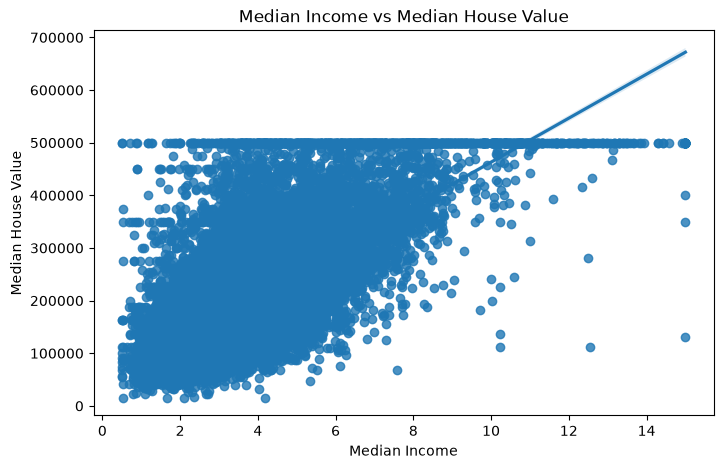

In [17]:
# Scatter Plot with Regression Line
plt.figure(figsize=(8, 5))
sns.regplot(
    x="median_income",
    y="median_house_value",
    data=df
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

extra question 

In [19]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("housing.csv")

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  


In [20]:
numerical_data = df.select_dtypes(include="number")

print(numerical_data.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')


Q.1 — Complete Correlation Matrix

In [21]:
correlation_matrix = numerical_data.corr()

print(correlation_matrix)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

In [22]:
print(correlation_matrix.round(4))

                    longitude  latitude  housing_median_age  total_rooms  \
longitude              1.0000   -0.9247             -0.1082       0.0446   
latitude              -0.9247    1.0000              0.0112      -0.0361   
housing_median_age    -0.1082    0.0112              1.0000      -0.3613   
total_rooms            0.0446   -0.0361             -0.3613       1.0000   
total_bedrooms         0.0696   -0.0670             -0.3205       0.9304   
population             0.0998   -0.1088             -0.2962       0.8571   
households             0.0553   -0.0710             -0.3029       0.9185   
median_income         -0.0152   -0.0798             -0.1190       0.1980   
median_house_value    -0.0460   -0.1442              0.1056       0.1342   

                    total_bedrooms  population  households  median_income  \
longitude                   0.0696      0.0998      0.0553        -0.0152   
latitude                   -0.0670     -0.1088     -0.0710        -0.0798   
housing_

In [25]:
corr = correlation_matrix.copy()

# Replace diagonal values with NaN
for i in range(len(corr)):
    corr.iloc[i, i] = np.nan

strongest_positive = corr.stack().idxmax()
strongest_positive_value = corr.stack().max()

print("Strongest positive correlation:", strongest_positive)
print("Value:", strongest_positive_value)

Strongest positive correlation: ('total_bedrooms', 'households')
Value: 0.9797282708045709


In [26]:
strongest_negative = corr.stack().idxmin()
strongest_negative_value = corr.stack().min()

print("Strongest negative correlation:", strongest_negative)
print("Value:", strongest_negative_value)

Strongest negative correlation: ('longitude', 'latitude')
Value: -0.9246644339150368


In [27]:
weakest = corr.stack().abs().idxmin()
weakest_value = corr.loc[weakest[0], weakest[1]]

print("Weakest correlation:", weakest)
print("Value:", weakest_value)

Weakest correlation: ('population', 'median_income')
Value: 0.004834345627653126


Q.2 — Regression Models

In [28]:
X = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "households"
    ]
]

y = df["median_house_value"]

In [29]:
multiple_model = LinearRegression()

multiple_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[45969.66, 1842.15, -13.95, -39.45, 214.35]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['median_income','housing_median_age','total_rooms','population', 'households']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.793e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [30]:
y_pred_multiple = multiple_model.predict(X)

In [31]:
r2_multiple = r2_score(y, y_pred_multiple)
mse_multiple = mean_squared_error(y, y_pred_multiple)

print("Multiple Regression R2:", r2_multiple)
print("Multiple Regression MSE:", mse_multiple)

Multiple Regression R2: 0.5629054644856253
Multiple Regression MSE: 5820133599.282842


In [32]:
X_simple = df[["median_income"]]
y = df["median_house_value"]

In [33]:
simple_model = LinearRegression()

simple_model.fit(X_simple, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41793.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.509e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [34]:
y_pred_simple = simple_model.predict(X_simple)

In [35]:
r2_simple = r2_score(y, y_pred_simple)
mse_simple = mean_squared_error(y, y_pred_simple)

print("Simple Regression R2:", r2_simple)
print("Simple Regression MSE:", mse_simple)

Simple Regression R2: 0.47344749180719903
Simple Regression MSE: 7011311502.929527


In [36]:
comparison = pd.DataFrame({
    "Model": ["Simple Regression", "Multiple Regression"],
    "R2": [r2_simple, r2_multiple],
    "MSE": [mse_simple, mse_multiple]
})

print(comparison)

                 Model        R2           MSE
0    Simple Regression  0.473447  7.011312e+09
1  Multiple Regression  0.562905  5.820134e+09


Q.3 — Correlation Between total_rooms and median_house_value

In [37]:
correlation = df["total_rooms"].corr(
    df["median_house_value"]
)

print("Correlation:", correlation)

Correlation: 0.1341531138065631


In [38]:
print(round(correlation, 4))

0.1342
